<a href="https://colab.research.google.com/github/huyle31251027190/BTVN-AI/blob/main/BTVNAI_25_5_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install mtcnn opencv-python tensorflow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 63.2 MB/s eta 0:00:00


In [ ]:
!pip uninstall -y lz4
!pip install --no-cache-dir lz4
import os
os.kill(os.getpid(), 9)

Found existing installation: lz4 4.4.5
Uninstalling lz4-4.4.5:
  Successfully uninstalled lz4-4.4.5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 122.7 MB/s eta 0:00:00


OSError: Unable to synchronously open file (truncated file: eof = 66060288, sblock->base_addr = 0, stored_eof = 70536008)

[INFO] Đang tải mô hình...


[INFO] Đang tải nhãn...
[INFO] Số lớp nhãn: 35
[INFO] Đọc ảnh...
[INFO] Khởi tạo MTCNN...
[INFO] Đang phát hiện khuôn mặt...
[INFO] Phát hiện được 1 khuôn mặt.

FACE #1
Result    : ✓ Lê Minh Huy
Confidence: 84.86%
Top 3:
  1. Lê Minh Huy                        84.86%
  2. Huỳnh Vũ Khánh Duy               1.47%
  3. Trần Anh Khôi - selfie           1.46%


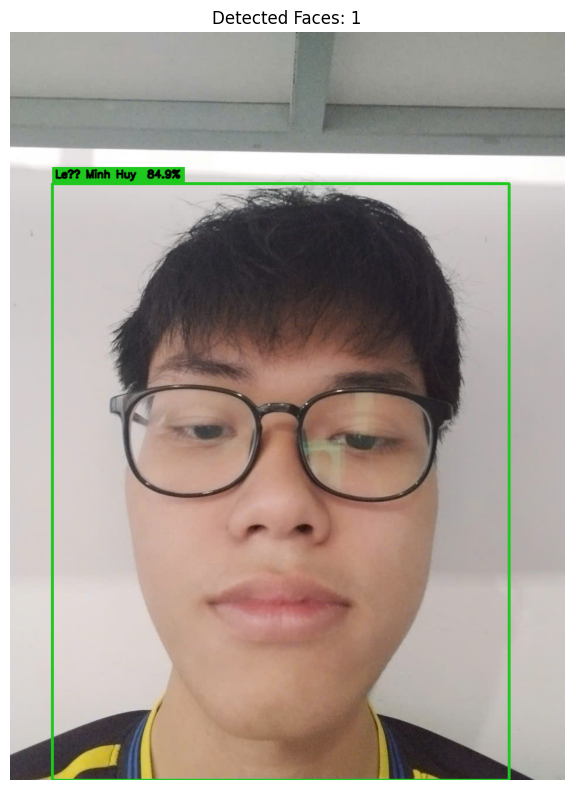

In [4]:
# ==============================================================
#  PREDICT_FACE_V2.PY — Nhận diện khuôn mặt với CNN + MTCNN
# ==============================================================

import cv2
import json
import numpy as np
import matplotlib.pyplot as plt

from mtcnn import MTCNN
from tensorflow.keras.models import load_model


# ======================== CẤU HÌNH ========================
MODEL_PATH = "/content/face_recognition_cnn.h5"
LABEL_PATH = "/content/memberclass_cnn.json"
IMAGE_PATH = "/content/z7876296175768_2cc2ea1b7ac26ed8451be06552d7b30a.jpg"   # đổi thành ảnh bạn muốn test

TARGET_SIZE = (160, 160)
CONFIDENCE_THRESHOLD = 0.80
PADDING_RATIO = 0.20


# ======================== LOAD NHÃN ========================
def load_class_labels(label_path: str) -> dict:
    with open(label_path, "r", encoding="utf-8") as f:
        class_indices = json.load(f)
    return {int(v): k for k, v in class_indices.items()}


# ======================== TIỀN XỬ LÝ ========================
def preprocess_face(face_rgb: np.ndarray) -> np.ndarray:
    if face_rgb is None or face_rgb.size == 0:
        raise ValueError("Ảnh khuôn mặt rỗng hoặc không hợp lệ.")

    face_resized = cv2.resize(face_rgb, TARGET_SIZE, interpolation=cv2.INTER_AREA)
    face_norm = face_resized.astype("float32") / 255.0
    face_batch = np.expand_dims(face_norm, axis=0)
    return face_batch


# ======================== DỰ ĐOÁN ========================
def predict_face(model, face_rgb: np.ndarray, labels: dict, threshold: float = CONFIDENCE_THRESHOLD):
    face_input = preprocess_face(face_rgb)
    preds = model.predict(face_input, verbose=0)[0]

    pred_idx = int(np.argmax(preds))
    confidence = float(preds[pred_idx])

    top3_idx = np.argsort(preds)[::-1][:3]
    top3 = [(labels.get(int(i), "Unknown"), float(preds[i])) for i in top3_idx]

    if confidence < threshold:
        return "Unknown", confidence, top3

    return labels.get(pred_idx, "Unknown"), confidence, top3


# ======================== VẼ KẾT QUẢ ========================
def draw_face_box(image_rgb: np.ndarray, x: int, y: int, w: int, h: int,
                  name: str, confidence: float, threshold: float):
    color = (30, 200, 30) if confidence >= threshold and name != "Unknown" else (255, 130, 40)
    label_text = f"{name}  {confidence * 100:.1f}%"

    cv2.rectangle(image_rgb, (x, y), (x + w, y + h), color, 3)

    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.6
    thickness = 2
    (txt_w, txt_h), baseline = cv2.getTextSize(label_text, font, font_scale, thickness)

    # Đặt nhãn không vượt khỏi khung ảnh
    img_h, img_w = image_rgb.shape[:2]
    label_x1 = max(0, x)
    label_y2 = max(txt_h + baseline + 8, y)
    label_y1 = max(0, label_y2 - txt_h - baseline - 8)
    label_x2 = min(img_w - 1, label_x1 + txt_w + 10)

    cv2.rectangle(image_rgb, (label_x1, label_y1), (label_x2, label_y2), color, -1)

    text_x = label_x1 + 5
    text_y = min(img_h - 1, label_y2 - baseline - 4)

    cv2.putText(
        image_rgb,
        label_text,
        (text_x, text_y),
        font,
        font_scale,
        (0, 0, 0),
        thickness,
        cv2.LINE_AA
    )


# ======================== MAIN ========================
def main():
    print("[INFO] Đang tải mô hình...")
    model = load_model(MODEL_PATH)

    print("[INFO] Đang tải nhãn...")
    labels = load_class_labels(LABEL_PATH)
    print(f"[INFO] Số lớp nhãn: {len(labels)}")

    print("[INFO] Đọc ảnh...")
    image_bgr = cv2.imread(IMAGE_PATH)
    if image_bgr is None:
        raise FileNotFoundError(f"Không đọc được ảnh: {IMAGE_PATH}")

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    print("[INFO] Khởi tạo MTCNN...")
    detector = MTCNN()

    print("[INFO] Đang phát hiện khuôn mặt...")
    faces = detector.detect_faces(image_rgb)

    if not faces:
        print("[WARN] Không phát hiện khuôn mặt nào.")
        plt.figure(figsize=(8, 6))
        plt.imshow(image_rgb)
        plt.axis("off")
        plt.show()
        return

    print(f"[INFO] Phát hiện được {len(faces)} khuôn mặt.\n")

    for i, face_data in enumerate(faces, start=1):
        x, y, w, h = face_data["box"]

        # box MTCNN đôi khi có tọa độ âm
        pad_x = int(w * PADDING_RATIO)
        pad_y = int(h * PADDING_RATIO)

        x1 = max(0, x - pad_x)
        y1 = max(0, y - pad_y)
        x2 = min(image_rgb.shape[1], x + w + pad_x)
        y2 = min(image_rgb.shape[0], y + h + pad_y)

        face_crop = image_rgb[y1:y2, x1:x2]

        if face_crop.size == 0:
            print(f"  [!] Khuôn mặt #{i}: crop rỗng, bỏ qua.")
            continue

        name, confidence, top3 = predict_face(model, face_crop, labels)

        draw_face_box(
            image_rgb,
            x1, y1, x2 - x1, y2 - y1,
            name, confidence, CONFIDENCE_THRESHOLD
        )

        status = "✓" if (name != "Unknown" and confidence >= CONFIDENCE_THRESHOLD) else "?"
        print("=" * 60)
        print(f"FACE #{i}")
        print(f"Result    : {status} {name}")
        print(f"Confidence: {confidence * 100:.2f}%")
        print("Top 3:")
        for rank, (person, score) in enumerate(top3, start=1):
            print(f"  {rank}. {person:<35} {score * 100:.2f}%")

    print("=" * 60)

    plt.figure(figsize=(12, 8))
    plt.imshow(image_rgb)
    plt.axis("off")
    plt.title(f"Detected Faces: {len(faces)}")
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()